## What is InfluxDB?

**InfluxDB** is a high-performance **Time-Series Database (TSDB)**. Unlike a traditional database (like MySQL) that is built for relationships between data, InfluxDB is optimized specifically for **stamped data**—information that changes over time.

Think of it as a specialized "storage locker" for logs, sensor readings, stock prices, and real-time analytics where the most important question is always: *"What happened at [Time X]?"*

---

### Why Use It?
* **High-Speed Ingestion:** It can handle millions of data points per second.
* **Automatic Expiry:** like with `autogen`, it can automatically delete old data to save space.
* **Time-Centric Functions:** It has built-in math for time, like "Give me the average temperature every 5 minutes for the last 10 hours."
* **Compression:** It squeezes time-series data down to a fraction of its original size.



---

### What is InfluxQL?
**InfluxQL** is the language used to talk to InfluxDB (versions 1.x and 2.x in compatibility mode). 

If you already know SQL, you’re 90% of the way there. It was designed to look and feel like standard SQL so that developers wouldn't have to learn an entirely new syntax.

#### The Similarities:
* You use `SELECT` to get data.
* You use `FROM` to specify the measurement.
* You use `WHERE` to filter by tags or time.
* You use `GROUP BY` to bundle data.

#### The Differences:
While it looks like SQL, it has "Time-Series Superpowers." For example:
```sql
SELECT MEAN("T1") FROM "Temperature" 
WHERE time > now() - 1h 
GROUP BY time(10m)
```
* **`now() - 1h`**: A built-in way to say "in the last hour."
* **`GROUP BY time(10m)`**: This automatically "buckets" your data into 10-minute chunks and calculates the average for each. A standard database would require a massive, complex query to do this.

---

### When to use InfluxDB vs. a Standard Database?
| Feature | InfluxDB | Standard SQL (PostgreSQL/MySQL) |
| :--- | :--- | :--- |
| **Main Focus** | Events and Metrics (Time) | Relationships (People, Orders, Products) |
| **Data Updates** | Rarely (Usually "Write once, Read many") | Frequent (Updating a user's profile) |
| **Old Data** | Deleted automatically via Retention Policies | Usually kept forever or manually archived |



### Recap
InfluxDB is the database you use when you have "Too Much Data." If you tried to store 1-second interval sensor data for a year in a regular database, it would eventually crawl to a halt and cry. InfluxDB just asks, "Is that all you've got?"

Are you moving your data into InfluxDB to visualize it in a tool like Grafana, or are you doing the analysis directly in Python?

In [1]:
from influxdb import InfluxDBClient
import random
import numpy as np
import time

host = '149.62.71.186'
user = 'admin'
password = 'fis_influx'
port=8086
client = InfluxDBClient(host, port, user, password)



In [2]:
#show existing databases
dbs = client.get_list_database()
for db in dbs:
   print(db.get('name'))

InfluxDB Naloga 1
CURLdb
Database2026
Naloga 4
curldb2026
MojaSlovenija
anonymous db
InfluxDBVaje9.4.
InfluxDB Vaje123
InfluxDB_Vaje123
test1234


In [ ]:
#delete all previous databases
dbs = client.get_list_database()
for db in dbs:
   client.drop_database(db.get('name'))

In [ ]:
#create a database
client.create_database('InfluxDB Naloga 1')

In [2]:
#switch to a database
client.switch_database('InfluxDB Naloga 1')

In [4]:
#send data to the database
t = 0
while True:
    time.sleep(0.1)
    t += 1
    value = np.sin(0.1*t) + np.random.normal(0,0.1) + 2

    data = [{"measurement": "Temperature",
                "fields": {
                    "T1" : value, "T2" : value + 1 + np.random.normal(0,0.3)}},
           {"measurement": "Pressure",
                "fields": {
                    "P1" : np.exp(value**2), "P2" : np.exp(value**2)  + np.random.normal(0,300)}}]

    client.write_points(data)

KeyboardInterrupt: 

In [3]:
#Get results from the datase
result=client.query('SELECT "T1" FROM "InfluxDB Naloga 1"."autogen"."Temperature"')
points = result.get_points()
times, values = [],[]
for point in points:
    print(point['time'], point['T1'])
    times.append(point['time'])
    values.append(point['T1'])

2026-04-09T06:47:50.980001Z 1.9780961023534218
2026-04-09T06:47:51.132650Z 2.2364134325652456
2026-04-09T06:47:51.256127Z 2.301862843081625
2026-04-09T06:47:51.377842Z 2.4836193832314084
2026-04-09T06:47:51.501352Z 2.489398219780575
2026-04-09T06:47:51.622695Z 2.5876976727811445
2026-04-09T06:47:51.745933Z 2.618621907398163
2026-04-09T06:47:51.868827Z 2.7146340908525497
2026-04-09T06:47:51.991994Z 2.7581679293083265
2026-04-09T06:47:52.112503Z 2.773290305855684
2026-04-09T06:47:52.234426Z 2.9971324526888075
2026-04-09T06:47:52.355970Z 3.153043195208815
2026-04-09T06:47:52.475930Z 2.9366536477180265
2026-04-09T06:47:52.597836Z 3.0059934647003987
2026-04-09T06:47:52.719928Z 2.7989673706526936
2026-04-09T06:47:52.841882Z 2.9915023823441205
2026-04-09T06:47:52.964698Z 2.872571084242063
2026-04-09T06:47:53.089832Z 3.0820635047494602
2026-04-09T06:47:53.213948Z 2.7208284865804515
2026-04-09T06:47:53.339932Z 2.9551011221545367
2026-04-09T06:47:53.462821Z 2.958119513010975
2026-04-09T06:47:53.

Text(0, 0.5, 'T1')

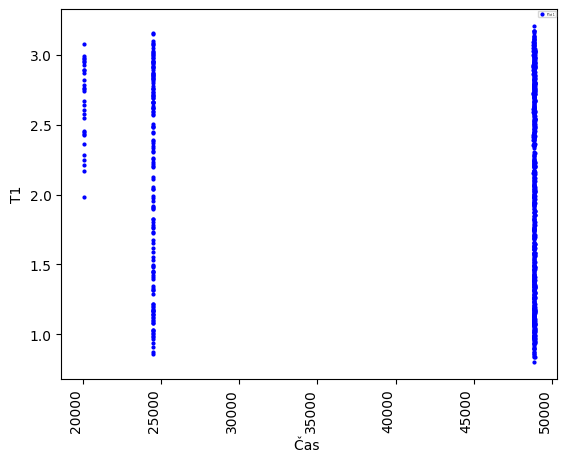

In [6]:
import matplotlib.pyplot as plt

#times2 is in seconds instead if a timestamp format
times2 = []
for i in range(len(times)):
    hms = times[i][11:-1].split(':')
    
    times2.append(int(hms[0])*3600 + int(hms[1])*60 + float(hms[2]))
    
plt.plot(times2, values, 'o', markersize = 2, color = 'blue')
plt.xticks(rotation=90, ha='right')  # 'ha' for horizontal alignment
plt.legend(['Plot 1', 'Plot 2'], fontsize = 2)

plt.xlabel('Čas ')
plt.ylabel('T1')

In [ ]:
#delete time series 
client.delete_series('CURLdb', 'Temperature')